## Is it a bird?

In [10]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings

warnings.filterwarnings("ignore")
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [9]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai 'duckduckgo_search>=6.2'

In 2015 the idea of creating a computer system that could recognise birds was considered so outrageously challenging that it was the basis of [this XKCD joke](https://xkcd.com/1425/):

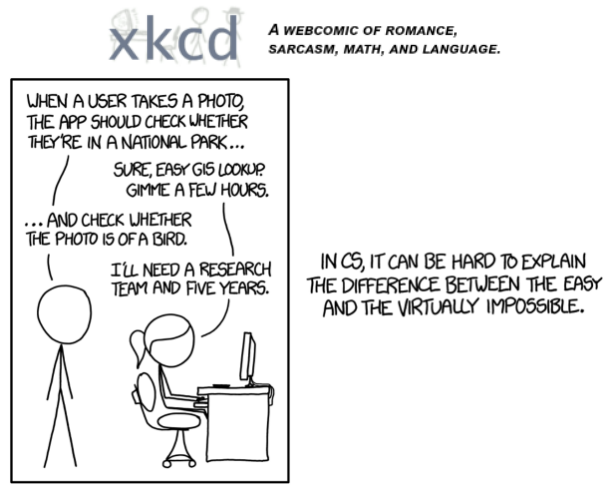

But today, we can do exactly that, in just a few minutes, using entirely free resources!

The basic steps we'll take are:

1. Use DuckDuckGo to search for images of "bird photos"
1. Use DuckDuckGo to search for images of "forest photos"
1. Fine-tune a pretrained neural network to recognise these two groups
1. Try running this model on a picture of a bird and see if it works.

## Step 1: Download images of birds and non-birds

In [12]:
from duckduckgo_search import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=200): 
    print(f"Searching for '{keywords}")
    time.sleep(1)
    with DDGS() as ddgs:
        results = [r['image'] for r in ddgs.images(keywords, region = 'wt-wt', max_results = max_images)]
    return L(results)
import time, json

Let's start by searching for a bird photo and seeing what kind of result we get. We'll start by getting URLs from a search:

In [5]:
#NB: `search_images` depends on duckduckgo.com, which doesn't always return correct responses.
#    If you get a JSON error, just try running it again (it may take a couple of tries).
urls = search_images('bird photos', max_images=200)
urls[0]

Searching for 'bird photos


/tmp/ipykernel_6398/2400087681.py:7: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


RatelimitException: https://duckduckgo.com/i.js?o=json&q=bird+photos&l=wt-wt&vqd=4-113334434899884965559421497140699631219&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit

...and then download a URL and take a look at it:

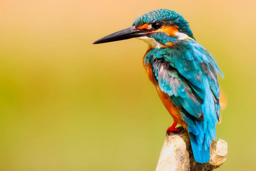

In [ ]:
from fastdownload import download_url
dest = Path('bird.jpg')
if not dest.exists():
    download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

Computers need numbers to work with, but luckily images are made of numbers.
Using tools like ***"Pixspy"***, we can observe that every image is actually a dense grid of pixels defined by the RGB model. Each pixel consists of a trplet of numbers ranging from 0 (no color) to 255(max intesity) for each channel.

For a Deep Learning Model, an image is a **Tensor** (a 3D matrix of Height x Width x 3 channels). By identifying these numerical pattern, the AI can perform the mathematical operations necessary to recognize shapes and classify the image

In [ ]:
pixel_data = array(im)

print(f"RGB of the pixel in [0,0]:  {pixel_data[0,0]}")

RGB of the pixel in [0,0]:  [249 190 132]


Now let's do the same with "forest photos":

Searching for 'forest photos


/tmp/ipykernel_9176/2400087681.py:7: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


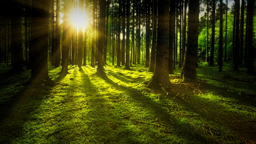

In [ ]:
download_url(search_images('forest photos', max_images=200)[0], 'forest.jpg', show_progress=False)
Image.open('forest.jpg').to_thumb(256,256)

Our searches seem to be giving reasonable results, so let's grab a few examples of each of "bird" and "forest" photos, and save each group of photos to a different folder:

In [ ]:
searches = 'forest','bird'
path = Path('bird_or_not')

print(path)

for o in searches:
    dest = (path/o)
    # 'parents = true' create a package 'bird_or_not' if it doesn't exist
    dest.mkdir(exist_ok = True, parents = True)
    print(dest)
    results = search_images(f'{o} photo')
    download_images(dest, urls = results[:200])
    resize_images(dest, max_size = 400, dest = dest)

bird_or_not
bird_or_not/forest
Searching for 'forest photo


/tmp/ipykernel_9176/2400087681.py:7: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


RatelimitException: https://duckduckgo.com/i.js?o=json&q=forest+photo&l=wt-wt&vqd=4-208279535551154257986828024790858954071&p=1&f=%2C%2C%2C%2C%2C 403 Ratelimit

We run the following code for verify if there are any photos on the package we have created

In [ ]:
files = get_image_files(path)
print(f"Images founded: {len(files)}")

if len(files) > 0:
    print(f"Path : {files[0]}")

Images founded: 2
Path : bird_or_not/bird.jpg


## Step 2: Train our model

Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [ ]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it.

In particular, 'DataBlock' gives to the fast.ai library all the information it needs to create a computer vision model

In [ ]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    # get all the image files that we just downloaded
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

# show some of the images file from the DataBlock
dls.show_batch(max_n=6) # shows 6 images

ValueError: This DataLoader does not contain any batches

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, "bird" or "forest").

    get_items=get_image_files, 

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in, which will be *bird* or *forest*).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [13]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

NameError: name 'vision_learner' is not defined

This code run through every photo of those 400 and for the ones that are forest it's going to learn a bit more about what a forest looks like and for the ones that are bird it'll learn a bit more about what bird looks like

Generally when I run this I see 100% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

## Step 3: Use our model (and build your own!)

Let's see what our model thinks about that bird we downloaded at the start:

In [19]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

This is a: images.
Probability it's a bird: 1.0000


Good job, resnet18. :)

So, as you see, in the space of a few years, creating computer vision classification models has gone from "so hard it's a joke" to "trivially easy and free"!

It's not just in computer vision. Thanks to deep learning, computers can now do many things which seemed impossible just a few years ago, including [creating amazing artworks](https://openai.com/dall-e-2/), and [explaining jokes](https://www.datanami.com/2022/04/22/googles-massive-new-language-model-can-explain-jokes/). It's moving so fast that even experts in the field have trouble predicting how it's going to impact society in the coming years.

One thing is clear -- it's important that we all do our best to understand this technology, because otherwise we'll get left behind!

Now it's your turn. Click "Copy & Edit" and try creating your own image classifier using your own image searches!

If you enjoyed this, please consider clicking the "upvote" button in the top-right -- it's very encouraging to us notebook authors to know when people appreciate our work.

## MY CLASSIFIER

I'm going to build an image classifier that can distinguish between dogs and cats using the dataset Oxford-IIIT Pet with ResNet-18 architecture.

In [6]:
from fastai.vision.all import *

# download the dataset Oxford-IIT Pet
path = untar_data(URLs.PETS)

In [ ]:
print(path)

/home/davidebui/.fastai/data/oxford-iiit-pet


This dataset organise the files based on their name, where the files that start with an uppercase letter are cats, and lowercase letter are dogs.
The function ***catOrdog*** is used to automatized this distinction.

Given that during the download of the dataset some images where corrupted or completely black, the function ***remove_corrupted*** iterate on the list of images to find the completely black photo and remove it

Numero file su filtered_list: 7390
Removed images: 0
Numero file su images_list: 7390


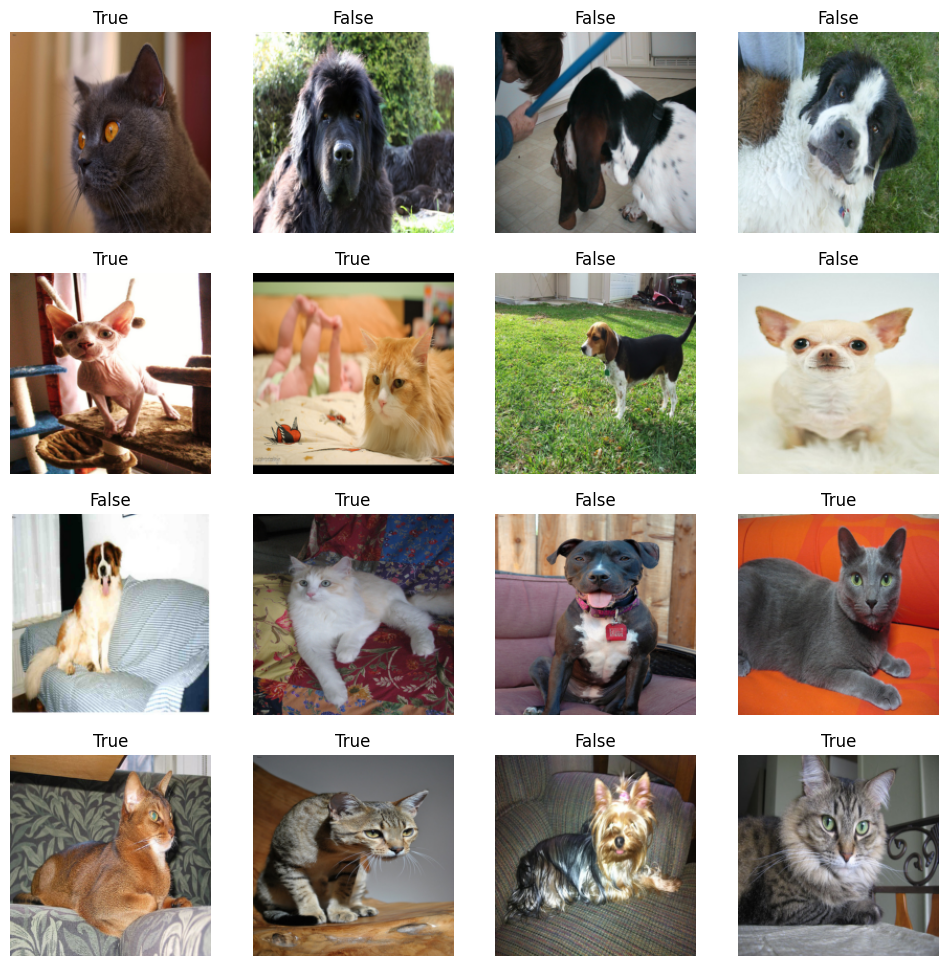

In [ ]:
from PIL import Image

def catOrdog(path):
    name = path.name
    if name[0].isupper():
        return True
    return False

def remove_corrupted(list):
    removed = 0
    for f in list:
        image = Image.open(f).convert('L')
        mean = np.array(image).mean()
        if mean < 5:
            f.unlink()
            removed+=1
    print(f"Removed images: {removed}")


filtered_list = get_image_files(path)
print(f"Number of files on filtered_list: {len(filtered_list)}")

remove_corrupted(filtered_list)

images_list = (get_image_files(path))

print(f"Number of files on images_list: {len(images_list)}")

my_dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    splitter=RandomSplitter(valid_pct=0.2, seed=40),
    get_y= catOrdog,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(images_list)

my_dls.show_batch(max_n = 16)

In [9]:
learn = vision_learner(my_dls, resnet18, metrics = error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.193696,0.078207,0.028417,09:17


epoch,train_loss,valid_loss,error_rate,time
0,0.069690,0.072679,0.016915,12:42


KeyboardInterrupt: 

/home/davidebui/.fastai/data/oxford-iiit-pet/annotations/trimaps/saint_bernard_151.png


This is a: images
Probability it's a cat: 1.0


This is a: images
Probability it's a cat: 1.0


This is a: images
Probability it's a cat: 1.0


This is a: images
Probability it's a cat: 1.0


This is a: images
Probability it's a cat: 1.0


This is a: images
Probability it's a cat: 1.0


This is a: images
Probability it's a cat: 1.0


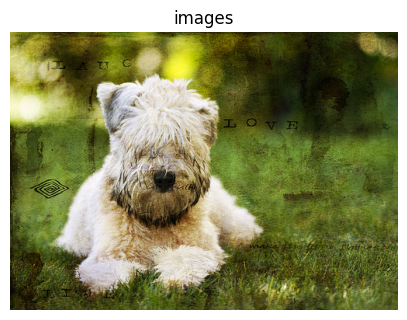

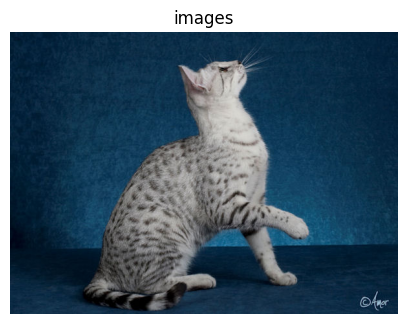

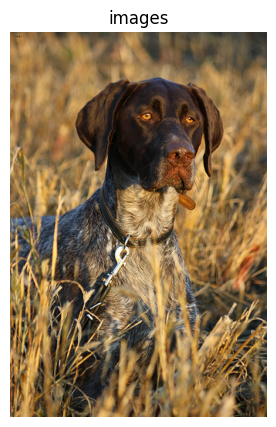

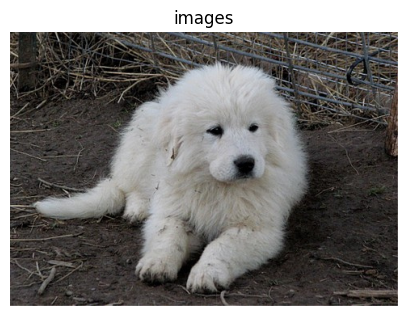

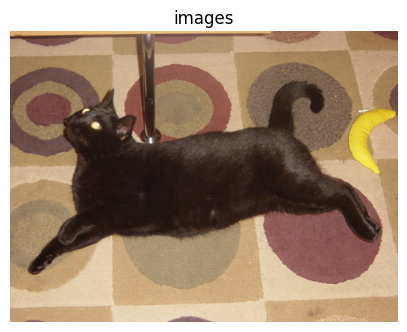

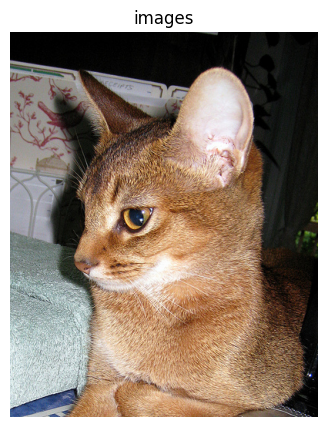

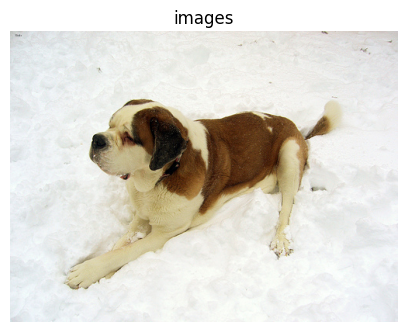

In [ ]:
import random


for i in random.sample(images_list, 10):
    
    is_cat, _ , prob = learn.predict(i)
    show_image(PILImage.create(i), title = is_cat)
    print(f"Is this a cat? {is_cat}")
    print(f"Probability: {max(prob)}")
